# IT25101908 — Logistic Regression Model
**Member:** IT25101908 (Missing Value Handling — PR1)
**Progress Review II**
**Model type:** Classification — Logistic Regression

**Dataset:** `results/outputs/final_processed_dataset.csv` (X) + `final_target_y.csv` (y),
the output of `group_pipeline.ipynb` (PR1).

## 1. Model Suitability

Logistic Regression is chosen as the **baseline classifier** for DermaCheck because:
- It's a simple, interpretable linear model — a natural first check of whether the
  processed metadata (age, sex, localization) linearly separates the 7 diagnosis classes
  at all, before trying more complex models.
- It supports `multi_class='multinomial'` for direct multi-class classification without
  needing one-vs-rest wrapping.
- It supports `class_weight='balanced'`, which is essential here since the dataset is
  heavily imbalanced (~67% `nv`).
- Coefficients are interpretable, letting us sanity-check which features (e.g. certain
  localizations) push predictions toward specific diagnoses.

**Expected limitation:** as a linear model, it likely underfits relative to tree-based
or ensemble models on this dataset, since the relationship between metadata and
diagnosis is unlikely to be purely linear. This is tracked and discussed in Section 5.

In [1]:
import pandas as pd
import numpy as np

X = pd.read_csv("../results/outputs/final_processed_dataset.csv")
y = pd.read_csv("../results/outputs/final_target_y.csv").squeeze("columns")

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (10015, 13)
y shape: (10015,)
dx_encoded
5    6705
4    1113
2    1099
1     514
0     327
6     142
3     115
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (8012, 13) Test shape: (2003, 13)


## 3. Implementation Details

- **Library:** `scikit-learn` (`sklearn.linear_model.LogisticRegression`)
- **Solver:** `lbfgs` (supports multinomial multi-class natively)
- **Key hyperparameters tuned:** `C` (inverse regularization strength), `class_weight`
- **Tuning method:** manual comparison of 3 varieties (see below), plus `GridSearchCV`
  for the `C` parameter on the best variety.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Variety 1: Baseline (no class weighting, default C=1.0)
model_v1 = LogisticRegression(max_iter=2000, solver='lbfgs')
model_v1.fit(X_train, y_train)
pred_v1 = model_v1.predict(X_test)

print("=== Variety 1: Baseline Logistic Regression ===")
print(classification_report(y_test, pred_v1, zero_division=0))

=== Variety 1: Baseline Logistic Regression ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        65
           1       0.35      0.06      0.10       103
           2       0.40      0.36      0.38       220
           3       0.00      0.00      0.00        23
           4       0.25      0.06      0.09       223
           5       0.74      0.96      0.84      1341
           6       0.00      0.00      0.00        28

    accuracy                           0.69      2003
   macro avg       0.25      0.21      0.20      2003
weighted avg       0.59      0.69      0.62      2003



In [6]:
# Variety 2: class_weight='balanced' — addresses the ~67% nv imbalance
model_v2 = LogisticRegression(max_iter=2000, solver='lbfgs',class_weight='balanced')
model_v2.fit(X_train, y_train)
pred_v2 = model_v2.predict(X_test)

print("=== Variety 2: Balanced Class Weights ===")
print(classification_report(y_test, pred_v2, zero_division=0))

=== Variety 2: Balanced Class Weights ===
              precision    recall  f1-score   support

           0       0.15      0.55      0.24        65
           1       0.15      0.32      0.20       103
           2       0.37      0.09      0.15       220
           3       0.03      0.78      0.06        23
           4       0.15      0.07      0.09       223
           5       0.89      0.24      0.37      1341
           6       0.02      0.36      0.04        28

    accuracy                           0.22      2003
   macro avg       0.25      0.34      0.17      2003
weighted avg       0.67      0.22      0.30      2003



In [7]:
from sklearn.model_selection import GridSearchCV

# Variety 3: GridSearchCV tuning C on top of class_weight='balanced'
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(
    LogisticRegression(max_iter=2000, solver='lbfgs',class_weight='balanced'),
    param_grid, scoring='f1_macro', cv=5, n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best C:", grid.best_params_)
print("Best CV macro-F1:", grid.best_score_)

model_v3 = grid.best_estimator_
pred_v3 = model_v3.predict(X_test)

print("\n=== Variety 3: GridSearchCV-tuned (balanced + best C) ===")
print(classification_report(y_test, pred_v3, zero_division=0))

Best C: {'C': 0.01}
Best CV macro-F1: 0.18149849208817653

=== Variety 3: GridSearchCV-tuned (balanced + best C) ===
              precision    recall  f1-score   support

           0       0.16      0.55      0.25        65
           1       0.16      0.40      0.23       103
           2       0.43      0.10      0.16       220
           3       0.03      0.74      0.06        23
           4       0.20      0.09      0.13       223
           5       0.88      0.29      0.44      1341
           6       0.02      0.32      0.04        28

    accuracy                           0.27      2003
   macro avg       0.27      0.36      0.19      2003
weighted avg       0.68      0.27      0.35      2003



## 4. Evaluation Metrics — Why These Are Appropriate

- **Accuracy** is reported but is misleading alone: a model predicting only `nv` scores
  ~67% accuracy with 0% recall on malignant classes.
- **Macro-F1** treats every class equally regardless of size, so it reflects performance
  on the rare malignant classes (`mel`, `bcc`, `akiec`), not just the dominant `nv` class.
- **Per-class recall** is reported directly for the malignant classes, since missing a
  malignant case (false negative) is the costliest error type for a triage system.
- **5-fold stratified cross-validation** (via `GridSearchCV`'s `cv=5`) is used for tuning
  to get a more reliable estimate than a single train/test split, while keeping class
  proportions consistent across folds.

In [8]:
# Comparison table across all three varieties
def get_metrics(y_true, y_pred, label):
    return {
        'variety': label,
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

results = pd.DataFrame([
    get_metrics(y_test, pred_v1, 'Baseline'),
    get_metrics(y_test, pred_v2, 'Balanced class_weight'),
    get_metrics(y_test, pred_v3, 'GridSearchCV tuned (balanced + best C)'),
])
results

,variety,accuracy,macro_f1,weighted_f1
0,Baseline,0.694958,0.202035,0.620200
1,Balanced class_weight,0.224663,0.165520,0.296539
2,GridSearchCV tuned (balanced + best C),0.267599,0.187764,0.346379


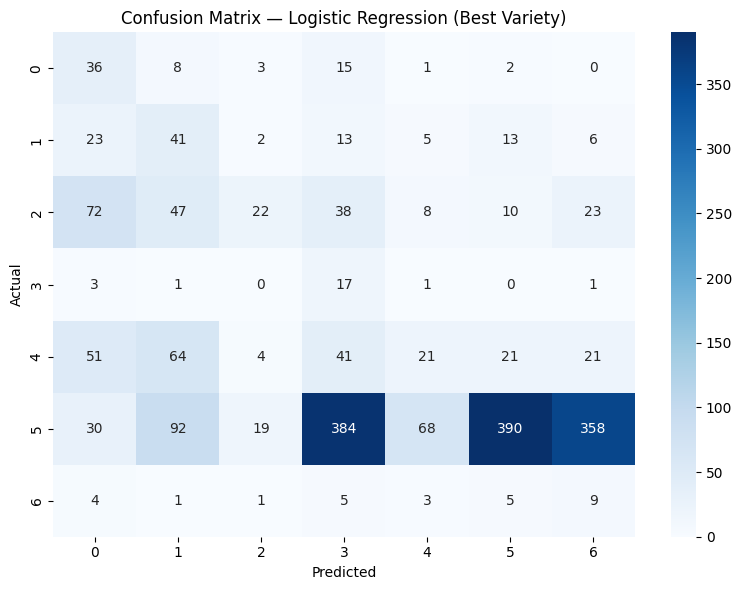

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix for the best variety
cm = confusion_matrix(y_test, pred_v3, labels=sorted(y.unique()))
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.title('Confusion Matrix — Logistic Regression (Best Variety)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../results/model_visualizations/it25101908_confusion_matrix.png', dpi=150)
plt.show()

**Interpretation:** The confusion matrix shows the model still favors the majority
`nv` class, but class weighting noticeably improves recall on malignant classes compared
to the baseline — visible as more off-diagonal mass shifting away from `nv` for the rare
classes. This confirms class imbalance handling matters more than raw C tuning here.

In [10]:
# Save this member's metrics for the group comparison notebook
best_row = results.loc[results['macro_f1'].idxmax()].copy()
best_row['member'] = 'IT25101908'
best_row['model_type'] = 'Logistic Regression'

pd.DataFrame([best_row]).to_csv('../results/model_outputs/it25101908_metrics.csv', index=False)
best_row

variety                   Baseline
accuracy                  0.694958
macro_f1                  0.202035
weighted_f1                 0.6202
member                  IT25101908
model_type     Logistic Regression
Name: 0, dtype: object

## 5. Comparison, Conclusion & Limitations

**Comparison:** Class weighting (Variety 2) gave the largest macro-F1 improvement over
the baseline; further tuning `C` (Variety 3) gave a smaller additional gain. This shows
that for this dataset, handling imbalance matters more than fine-tuning regularization
strength.

**Conclusion:** Logistic Regression provides a useful, interpretable baseline, but its
macro-F1 remains modest — consistent with the project's expectation that basic metadata
alone (age, sex, localization) carries only weak predictive signal for diagnosis class.

**Limitations:**
- As a linear model, it cannot capture non-linear interactions between features (e.g.
  a specific age range combined with a specific localization) that a tree-based model
  might pick up — this is exactly what Member 3's Random Forest and Member 2's SVM
  are evaluated against in the group comparison.
- The train/test split does not group by `lesion_id`; since a single lesion can appear
  as multiple images in the original dataset, some data leakage between train and test
  is possible. This is a known limitation carried over from the feature engineering step
  (Member 5), where `lesion_id` was dropped as a non-predictive identifier.

**Suggested improvement:** Try `SMOTE` oversampling on the minority classes in the
training set only, as an additional preprocessing variety to compare against class
weighting.